# VAE Implementation Notebook

The purpose of this notebook is to translate the ELBO derivation into a compact PyTorch implementation that remains readable to students who are seeing the method for the first time. The implementation deliberately stays small. We use grayscale images, a low-dimensional Gaussian latent variable, and a lightweight encoder-decoder pair. The objective is not to compete with industrial image generators, but to make visible the exact correspondence between the mathematics of the previous chapter and the tensors manipulated during training.

The guiding principle is that every line of code should answer a theoretical question. Where is the approximate posterior $q_\phi(\boldsymbol{z} | \boldsymbol{x})$ represented. Which tensors correspond to the mean and the variance. Where does the reparameterization trick appear. Which term in the code is the reconstruction log-likelihood surrogate, and which one is the Kullback-Leibler regularizer. Once those correspondences are clear, larger implementations become much easier to read.

This also makes the notebook a useful contrast point for the rest of the course. Compared with later GAN and diffusion implementations, the VAE code is compact enough that students can still hold almost the entire mathematical pipeline in their heads at once. That is why VAEs often remain the best first serious coding laboratory for probabilistic deep generative modeling.

## Imports and Basic Configuration

The notebook below assumes a standard PyTorch installation together with `torchvision`. The code is intentionally CPU-friendly and uses `FashionMNIST` as a simple image dataset, although the same logic applies to MNIST or to any other small grayscale dataset. The images are normalized to the interval $[0,1]$, which matches the use of a Bernoulli-style reconstruction term implemented through binary cross-entropy on sigmoid outputs.

The hyperparameters are chosen so the example can produce recognizable samples, not only execute quickly. A latent dimension of size $32$ is still small enough to discuss the bottleneck as an actual geometric constraint, while a convolutional encoder-decoder respects the image grid. These are the kinds of tradeoffs worth naming explicitly in class, because they teach students to see hyperparameters as modeling decisions rather than arbitrary constants copied from a repository.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)
num_workers = 2 if device.type == "cuda" else 0
project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"

# Settings
batch_size = 128
latent_dim = 32
base_channels = 32
lr = 2e-4
epochs = 30

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)

## Encoder and Decoder

We use a compact convolutional VAE. This is still simple enough to read in one notebook, but it respects locality and produces much better image samples than a flattened multilayer perceptron trained for a few epochs. The encoder maps the image to two vectors, $\boldsymbol{\mu}_\phi(\boldsymbol{x})$ and $\log \boldsymbol{\sigma}_\phi^2(\boldsymbol{x})$. The decoder maps a latent sample back to image logits, which are finally converted to pixel probabilities through a sigmoid.

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32, base_channels=32):
        super().__init__()
        # 28x28 -> 14x14 -> 7x7.
        self.encoder = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.SiLU(),
            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.SiLU(),
            nn.Flatten(),
        )
        encoded_dim = base_channels * 4 * 7 * 7
        self.mu_head = nn.Linear(encoded_dim, latent_dim)
        self.logvar_head = nn.Linear(encoded_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, encoded_dim),
            nn.SiLU(),
            nn.Unflatten(1, (base_channels * 4, 7, 7)),
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.SiLU(),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, 1, kernel_size=3, padding=1),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # Sample through parameter-free noise so gradients can flow to mu/logvar.
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        logits = self.decoder(z)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


model = VAE(latent_dim=latent_dim, base_channels=base_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

The method `reparameterize` is the code-level manifestation of the identity
:::{math}
\boldsymbol{z} = \boldsymbol{\mu}_\phi(\boldsymbol{x}) + \boldsymbol{\sigma}_\phi(\boldsymbol{x}) \odot \boldsymbol{\varepsilon},
\qquad
\boldsymbol{\varepsilon} \sim \mathcal{N}(\boldsymbol{0}, \boldsymbol{I}).
:::
It is worth pausing here pedagogically. Without this rewrite, a direct sample from a parameterized Gaussian would obstruct backpropagation through the stochastic node. After the rewrite, the random source is independent of the learnable parameters, so the computational graph remains differentiable with respect to $\phi$.

## ELBO Loss in Code

We now implement the negative ELBO. The reconstruction term is approximated by a binary cross-entropy between the reconstructed image probabilities and the input image. This corresponds to choosing a Bernoulli observation model for pixels. The KL term is the closed-form divergence between a diagonal Gaussian posterior and the standard Gaussian prior. Since optimizers minimize rather than maximize, we return the negative ELBO.

In [3]:
def elbo_loss(x, logits, mu, logvar):
    # Bernoulli reconstruction term for pixels in [0, 1].
    reconstruction = F.binary_cross_entropy_with_logits(
        logits,
        x,
        reduction="sum",
    )
    # Closed-form KL for a diagonal Gaussian encoder against N(0, I).
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    loss = reconstruction + kl
    return loss, reconstruction, kl

A subtle but important implementation detail is the use of logits instead of post-sigmoid probabilities inside `binary_cross_entropy_with_logits`. This is numerically more stable than applying a sigmoid manually and then feeding the result to a separate binary cross-entropy function. After training, however, we can still apply a sigmoid for visualization because we want actual pixel intensities in $[0,1]$.

The KL line in the function is equally important to decode for students. It is not a heuristic penalty chosen because Gaussian latents "feel natural". It is exactly the closed-form expression derived in Theorem {prf:ref}`thm-diagonal-gaussian-kl`, evaluated coordinatewise and summed across the minibatch. One of the nicest moments in teaching VAEs is when students realize that this compact piece of PyTorch code is not an approximation trick layered on top of theory, but the direct computational form of a theorem from the previous notebook.

## Training Loop

The training loop is intentionally written in explicit form rather than hidden behind utility classes. This is useful in a teaching context because students can see how the VAE objective is accumulated over a minibatch and how the encoder and decoder are updated jointly. The loss is normalized by the dataset size at the end of each epoch so that the reported scale does not depend on the minibatch size.

In [4]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_reconstruction = 0.0
    total_kl = 0.0

    for x, _ in tqdm(loader, desc="train", leave=False):
        x = x.to(device)

        optimizer.zero_grad()
        logits, mu, logvar = model(x)
        loss, reconstruction, kl = elbo_loss(x, logits, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_reconstruction += reconstruction.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "reconstruction": total_reconstruction / n,
        "kl": total_kl / n,
    }


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_reconstruction = 0.0
    total_kl = 0.0

    for x, _ in tqdm(loader, desc="eval", leave=False):
        x = x.to(device)
        logits, mu, logvar = model(x)
        loss, reconstruction, kl = elbo_loss(x, logits, mu, logvar)

        total_loss += loss.item()
        total_reconstruction += reconstruction.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "reconstruction": total_reconstruction / n,
        "kl": total_kl / n,
    }

In [5]:
history = {"train_loss": [], "train_kl": [], "val_loss": [], "val_kl": []}

for epoch in tqdm(range(epochs), desc="VAE epochs"):
    train_stats = train_epoch(model, train_loader, optimizer, device)
    val_stats = evaluate(model, test_loader, device)

    history["train_loss"].append(train_stats["loss"])
    history["train_kl"].append(train_stats["kl"])
    history["val_loss"].append(val_stats["loss"])
    history["val_kl"].append(val_stats["kl"])

    print(
        f"Epoch {epoch + 1:02d} | "
        f"train loss: {train_stats['loss']:.4f} | "
        f"train KL: {train_stats['kl']:.4f} | "
        f"val loss: {val_stats['loss']:.4f} | "
        f"val KL: {val_stats['kl']:.4f}"
    )

VAE epochs:   0%|          | 0/30 [00:00<?, ?it/s]

train:   0%|          | 0/469 [00:00<?, ?it/s]

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01 | train loss: 292.5206 | train KL: 18.8659 | val loss: 260.4534 | val KL: 18.7577


train:   0%|          | 0/469 [00:00<?, ?it/s]

...

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 29 | train loss: 238.4162 | train KL: 17.9529 | val loss: 240.1183 | val KL: 17.7134


train:   0%|          | 0/469 [00:00<?, ?it/s]

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 30 | train loss: 238.3244 | train KL: 17.9514 | val loss: 240.0256 | val KL: 17.9377


Tracking the KL term separately is pedagogically useful. At the beginning of training it may be very small or behave erratically, especially if the decoder learns to ignore the latent code. This phenomenon, often called posterior collapse in stronger sequence and image decoders, is worth discussing explicitly with students because it reveals that optimizing the ELBO involves a delicate balance between reconstruction quality and latent regularization.

The separate statistics also help diagnose milder pathologies before they become dramatic. If the KL term collapses almost to zero and reconstructions remain sharp, the decoder may be solving too much of the task without using the latent variable. If the KL term becomes very large while reconstructions stay poor, the encoder may be pushing too hard against the prior without learning a useful compression. Reading these quantities together is one of the simplest ways to teach students that the ELBO is not a single opaque number but a negotiated compromise between two modeling objectives.

## Reconstruction, Sampling, and Latent Interpolation

A generative model should be inspected from several viewpoints. Reconstruction shows whether the encoder-decoder pair preserves enough information. Prior sampling checks whether latent points drawn from $p(\boldsymbol{z})$ decode into plausible images. Latent interpolation reveals whether the learned representation changes smoothly. Each of these probes illustrates a different part of the theory.

In [6]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    logits, _, _ = model(x)
    # Sigmoid is only for visualization; training used logits directly.
    recon = torch.sigmoid(logits).view(-1, 1, 28, 28)

    grid = torch.cat([x.cpu(), recon.cpu()], dim=0)
    image = utils.make_grid(grid, nrow=n, pad_value=1.0)
    plt.figure(figsize=(1.5 * n, 3.0))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()


@torch.no_grad()
def show_samples(model, device, n=16):
    model.eval()
    z = torch.randn(n, latent_dim, device=device)
    logits = model.decode(z)
    samples = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()
    image = utils.make_grid(samples, nrow=4, pad_value=1.0)
    plt.figure(figsize=(6, 6))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()

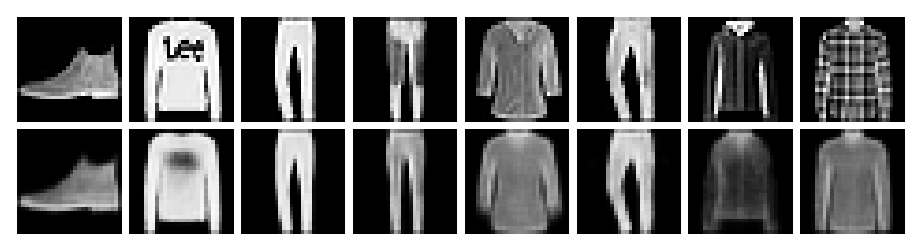

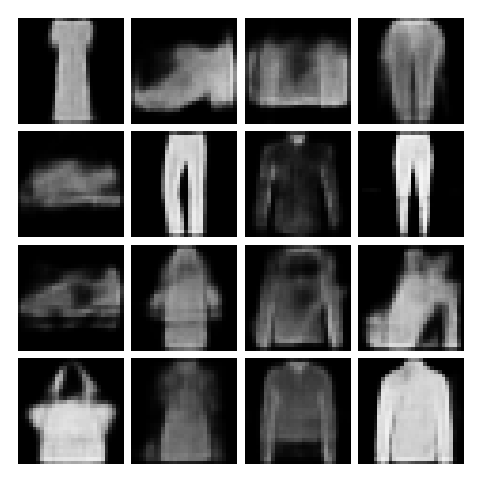

In [7]:
show_reconstructions(model, test_loader, device)
show_samples(model, device)

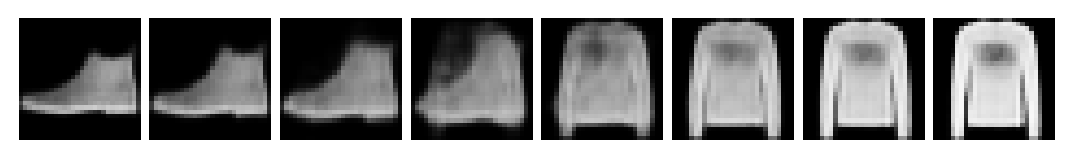

In [8]:
@torch.no_grad()
def interpolate(model, loader, device, steps=8):
    model.eval()
    x, _ = next(iter(loader))
    x0 = x[0:1].to(device)
    x1 = x[1:2].to(device)

    # Interpolate between posterior means to visualize latent geometry.
    mu0, _ = model.encode(x0)
    mu1, _ = model.encode(x1)

    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z = (1 - alphas) * mu0 + alphas * mu1
    logits = model.decode(z)
    images = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()

    grid = utils.make_grid(images, nrow=steps, pad_value=1.0)
    plt.figure(figsize=(1.7 * steps, 2.5))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()


interpolate(model, test_loader, device)

Interpolation is often the first moment when students feel the latent-variable idea concretely. If the model has learned a meaningful organization of the data, moving linearly in latent space produces structured and gradual semantic changes in image space. This does not prove that the latent space is disentangled, nor that linear interpolation is the theoretically correct path for every model, but it provides useful qualitative evidence that the prior and the decoder have learned a coherent geometry.

## Quantitative Evaluation with FID and KID

Visual inspection is essential, but it is not enough on its own. We can also compare VAE samples against real test images using **FID** and **KID**. On a small grayscale dataset such as `FashionMNIST`, the resulting values should be interpreted cautiously: they are useful for relative classroom comparison, not as headline benchmark numbers. Still, they are excellent for teaching how distribution-level evaluation works in practice.

The default `torchmetrics` implementations use an Inception-style feature extractor, so we must adapt our grayscale images to the expected three-channel format. We also keep the images in the $[0,1]$ range and cache the real features so they do not need to be recomputed if the dataset stays fixed.

In [9]:
def prepare_for_inception_metrics(images):
    # The default Inception feature extractor expects RGB-like inputs.
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


@torch.no_grad()
def compute_vae_fid_and_kid(model, real_loader, device, num_fake=1000):
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=False,
    ).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=10,
        subset_size=100,
        normalize=True,
        reset_real_features=False,
    ).to(device)

    # First accumulate features from real images.
    for real_images, _ in tqdm(real_loader, desc="real metrics", leave=False):
        real_images = prepare_for_inception_metrics(real_images.to(device))
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)

    # Then accumulate features from generated samples.
    generated = 0
    pbar = tqdm(total=num_fake, desc="VAE fake metrics", leave=False)
    while generated < num_fake:
        batch_n = min(batch_size, num_fake - generated)
        z = torch.randn(batch_n, latent_dim, device=device)
        logits = model.decode(z)
        fake_images = torch.sigmoid(logits).view(-1, 1, 28, 28)
        fake_images = prepare_for_inception_metrics(fake_images)
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()

    kid_mean, kid_std = kid.compute()
    return {
        "fid": fid.compute().item(),
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item(),
    }


metric_scores = compute_vae_fid_and_kid(model, test_loader, device)
print(metric_scores)

c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


real metrics:   0%|          | 0/79 [00:00<?, ?it/s]

VAE fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

{'fid': 89.02374116719241, 'kid_mean': 0.0771636962890625, 'kid_std': 0.00850323960185051}


This evaluation block also clarifies one of the VAE's characteristic tradeoffs. A VAE may reconstruct cleanly and organize latent space nicely, yet still obtain weaker FID or KID than a sharper generator because the decoded samples can look slightly smooth or blurry in feature space. That does not make the model useless. It means the metric is emphasizing a specific aspect of generative quality, namely closeness of the generated feature distribution to the real one.

## Practical Discussion

This simple implementation can be extended in several directions. Replacing the MLP with a convolutional encoder-decoder improves image quality and better respects spatial structure. Increasing the latent dimension gives the decoder more expressive freedom, though too large a latent space may weaken regularization. Changing the observation model alters the reconstruction term. For grayscale images in $[0,1]$, Bernoulli decoding is a common pedagogical choice, but Gaussian decoders are also standard in the literature.

It is also useful to prepare students for what "success" should look like in this notebook. Reconstructions should usually preserve the broad clothing category and silhouette, prior samples should look recognizable though somewhat blurry, and latent interpolations should change shape gradually rather than jump discontinuously. If outputs remain indistinct after several epochs, one should check tensor shapes, loss scaling, and whether the decoder is accidentally applying a sigmoid twice. If reconstructions are excellent but random samples are incoherent, that often signals a weakly organized latent space rather than a complete training failure.

The deeper lesson is that a VAE is not merely an autoencoder with noise added. It is a probabilistic model whose code reflects a specific decomposition of the log-likelihood surrogate. Once the student can identify the prior, posterior family, reparameterized sample, reconstruction model, and KL regularizer in code, the abstract derivation of the ELBO has already been internalized.